# Recinos Topic Model

In [1]:
import pandas as pd
import numpy as np

In [2]:
import plotly_express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set()

In [4]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.preprocessing import normalize

In [5]:
import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

In [30]:
from hac2 import HAC

# Get Data

In [6]:
OHCO = ['parte','capit','sent','token']

In [7]:
DOC = pd.read_csv("recinos-DOC.csv").set_index(OHCO[:2])
VOCAB = pd.read_csv("recinos-VOCABX.csv").set_index('term_str')

In [8]:
TOKEN = pd.read_csv("recinos-TOKEN.csv").set_index(OHCO)
DTM = TOKEN[TOKEN.token_pos.isin(['NOUN','PROPN','VERB'])].groupby(OHCO[:2]+['term_str']).term_str.count().unstack(fill_value=0)

In [9]:
STOP = VOCAB[VOCAB.stop == True].index
DTM = DTM[list(set(DTM.columns) - set(STOP))]

# CHUNK

In [61]:
bigline = (' '.join(DOC.doc_str.to_list())).split()
chunk_size = len(bigline) // 75 # 50
chunks = [bigline[i:i + chunk_size] for i in range(0, len(bigline), chunk_size)]

In [62]:
CHUNK = pd.DataFrame(chunks).apply(lambda x: ' '.join(map(str, x)), axis=1).to_frame('chunk_str')
CHUNK['level_1'] = CHUNK.index // 10
CHUNK['level_2'] = CHUNK.index % 10
CHUNK = CHUNK.reset_index(drop=True).set_index(['level_1', 'level_2'])
CHUNK.index.name = 'chunk_id'
CHUNK['n_chars'] = CHUNK.chunk_str.str.len()

In [63]:
CHUNK.head()

chunk_str  n_chars
level_1 level_2                                                            
0       0        Este es el principio de las antiguas historias...     2616
        1        Creador, el Formador, Tepeu, Gucumatz, los pro...     2821
        2        los animales pequeños del monte, los guardiane...     2918
        3        quisieron probar de nuevo a que los adoraran. ...     2886
        4        alba, que así seréis llamados por nuestras obr...     2714

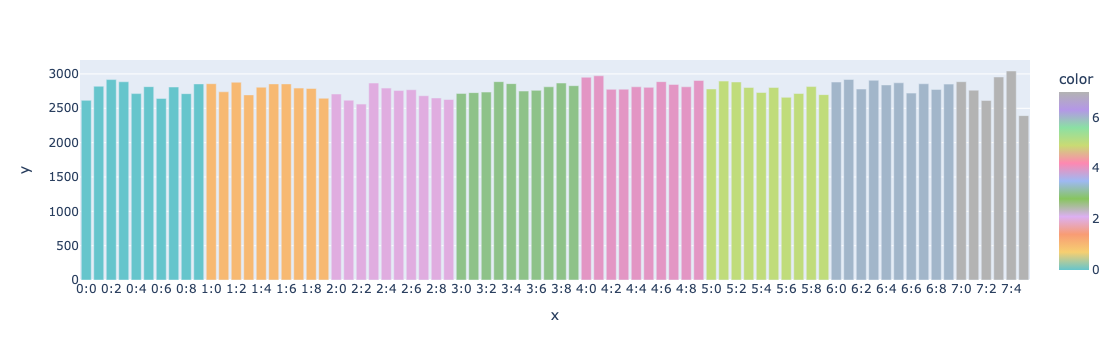

In [64]:
px.bar(x=[f"{idx[0]}:{idx[1]}" for idx in CHUNK.index.to_list()], y=CHUNK.n_chars, color=CHUNK.reset_index().level_1, 
      color_continuous_scale = px.colors.qualitative.Pastel)

# Create CTM

CTM means Chunk-Term Matrix..

In [65]:
STOPS = VOCAB[VOCAB.stop == True].index.to_list()

In [66]:
count_engine = CountVectorizer(
    lowercase=True,
    analyzer='word',
    token_pattern=r"(?u)\b[a-z'][a-z']+\b",
    max_df=.9,
    min_df=5, 
    stop_words=STOPS,
    ngram_range = (1,2)
)

In [67]:
CTM = pd.DataFrame(count_engine.fit_transform(CHUNK.chunk_str).toarray(), 
    columns=count_engine.get_feature_names_out(), 
    index=CHUNK.index)

In [68]:
CTM.head()

abuela  abuelo  abuelo padre  abuelos  abuelos padres  acab  \
level_1 level_2                                                                
0       0             2       2             0        0               0     0   
        1             0       0             0        0               0     0   
        2             0       0             0        0               0     0   
        3             6       2             0        0               0     0   
        4             0       0             0        0               0     0   

                 acab mahucutah  acabaron  acaso  acerca  ...  vinac  \
level_1 level_2                                           ...          
0       0                     0         0      0       0  ...      0   
        1                     0         0      0       0  ...      0   
        2                     0         0      0       0  ...      0   
        3                     0         0      0       1  ...      0   
        4                     0         0      0       0  ...      0   

                 vinieron  vino  vista  visto  volveremos  volvieron  vucub  \
level_1 level_2                                                               
0       0               0     0      1      0           0          0      0   
        1               2     0      0      0           0          0      0   
        2               0     0      0      0           0          0      0   
        3               0     0      1      0           0          0      0   
        4               0     1      0      0           0          0      0   

                 vucub caquix  vueltas  
level_1 level_2                         
0       0                   0        0  
        1                   0        0  
        2                   0        0  
        3                   0        0  
        4                   0        0  

[5 rows x 394 columns]

# Create TFIDF

In [69]:
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)
TFIDF_CHUNK = pd.DataFrame(tfidf_engine.fit_transform(CTM).toarray(), columns=CTM.columns, index=CTM.index)

# Compute NMF

In [70]:
n_topics = 5
nmf_engine = NMF(n_components=n_topics, max_iter=1000)
VS = TFIDF_CHUNK
THETA = pd.DataFrame(nmf_engine.fit_transform(VS), index=VS.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=VS.columns)
n_terms = 4
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T.to_frame('top_terms')
TOPIC

,top_terms
0,"balam, tohil, tribus, acab"
1,"hun, muchachos, vucub, hun vucub"
2,"cielo, tierra, hombre, formador"
3,"ahpop, ahau, ciudad, casas"
4,"abuela, hermanos, hunbatz, vieja"


In [71]:
PHIN = PHI + .01

PW = PHIN.sum() / PHIN.sum().sum()
PTw = (PHIN / PHIN.sum()).T
PT = (PHIN.T.sum() / PHIN.T.sum().sum())
PHI_DST = PTw * np.log(PTw/PT)
PHI_SAL = PHI_DST.T * PW
TOPIC['top_sal'] = PHI_SAL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

λ = .5
PHI_REL = λ * np.log(PHIN) + (1 - λ) * np.log(PHIN/PW)
TOPIC['top_rel'] = PHI_REL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_terms).index)).T

In [72]:
TOPIC

,top_terms,top_sal,top_rel
0,"balam, tohil, tribus, acab","balam, tohil, tribus, acab","balam, tohil, tribus, acab"
1,"hun, muchachos, vucub, hun vucub","hun, vucub, muchachos, hun vucub","hun, vucub, muchachos, hun vucub"
2,"cielo, tierra, hombre, formador","cielo, hombre, tierra, formador","cielo, hombre, formador, creador"
3,"ahpop, ahau, ciudad, casas","ahpop, ahau, rey, reyes","ahpop, ahau, rey, reyes"
4,"abuela, hermanos, hunbatz, vieja","abuela, hermanos, hunbatz, vieja","abuela, hermanos, hunbatz, vieja"


# View Topics over Narrative Time

In [73]:
# THETA.columns = TOPIC.top_sal

In [74]:
# fig, ax = plt.subplots(figsize=(10, 15))
# sns.heatmap(THETA[THETA > .1].fillna(0).T, cmap="YlGnBu", robust=True, square=True, cbar=False, ax=ax)
# plt.show()

In [75]:
x_axis_labels = [f"{idx[0]}:{idx[1]}" for i, idx in enumerate(THETA.T.columns.to_list())]
y_axis_labels =[f"{i}:{t}" for i, t in enumerate(TOPIC.top_terms.to_list())]

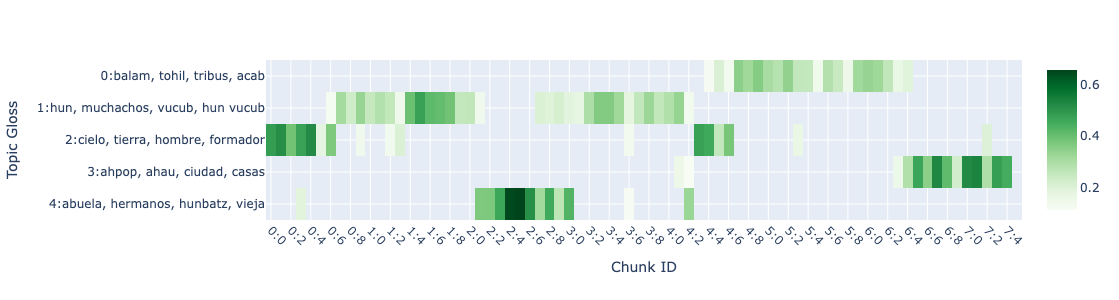

In [97]:
thresh = .11 # .08 #THETA.mean().mean()
px.imshow(THETA[THETA >= thresh].T, 
    x = x_axis_labels,
    y = y_axis_labels,
    color_continuous_scale=px.colors.sequential.Greens, 
    height=300, width=1200, aspect='auto')\
    .update_layout(
        xaxis_title="Chunk ID",
        yaxis_title="Topic Gloss",
        xaxis={ 'tickangle': 45},
        yaxis={ 'tickangle': 0}
)

## Distribution of Max Topic of Narrative Time

In [77]:
CHUNK['max_topic'] = THETA.idxmax(1).to_frame('max_topic')

In [78]:
# CHUNK

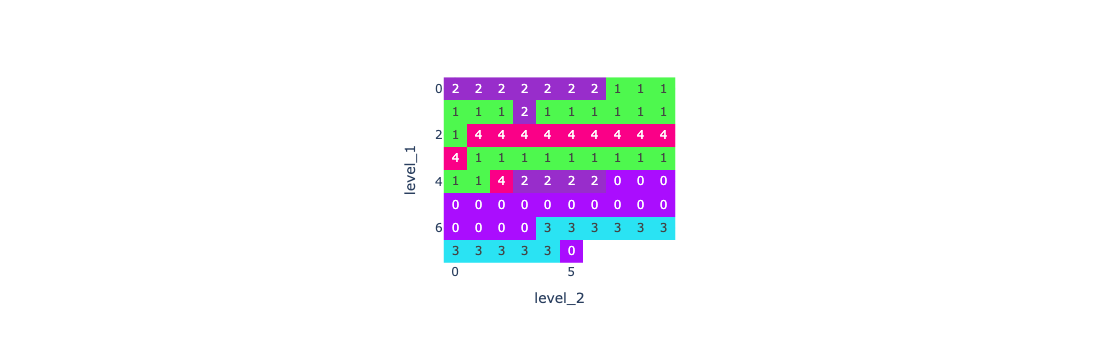

In [79]:
plot_grid(CHUNK.max_topic.unstack())

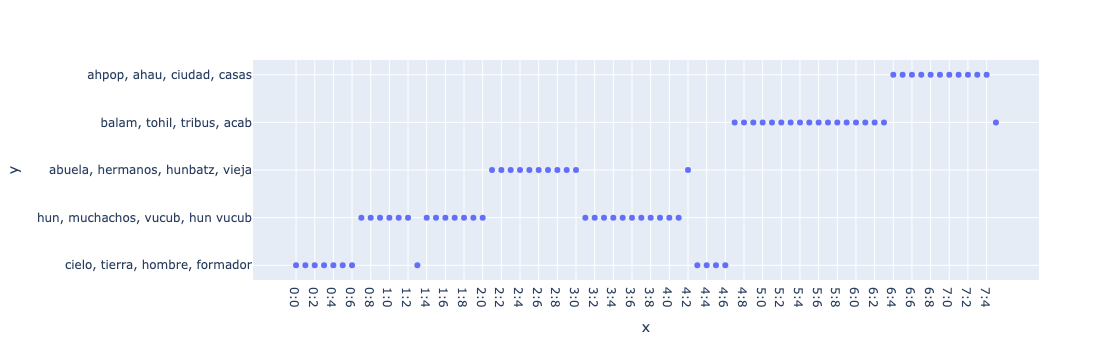

In [80]:
px.scatter(
    x = x_axis_labels, 
    y = [TOPIC.loc[t].top_terms for t in CHUNK.max_topic]
)

# Cluster Docs by Topics

In [81]:
metric = 'euclidean' # "euclidean", "l1", "l2", "manhattan", "cosine", or "precomputed"
linkage = 'ward' # 'ward', 'complete', 'average', 'single'

<Figure size 640x480 with 0 Axes>

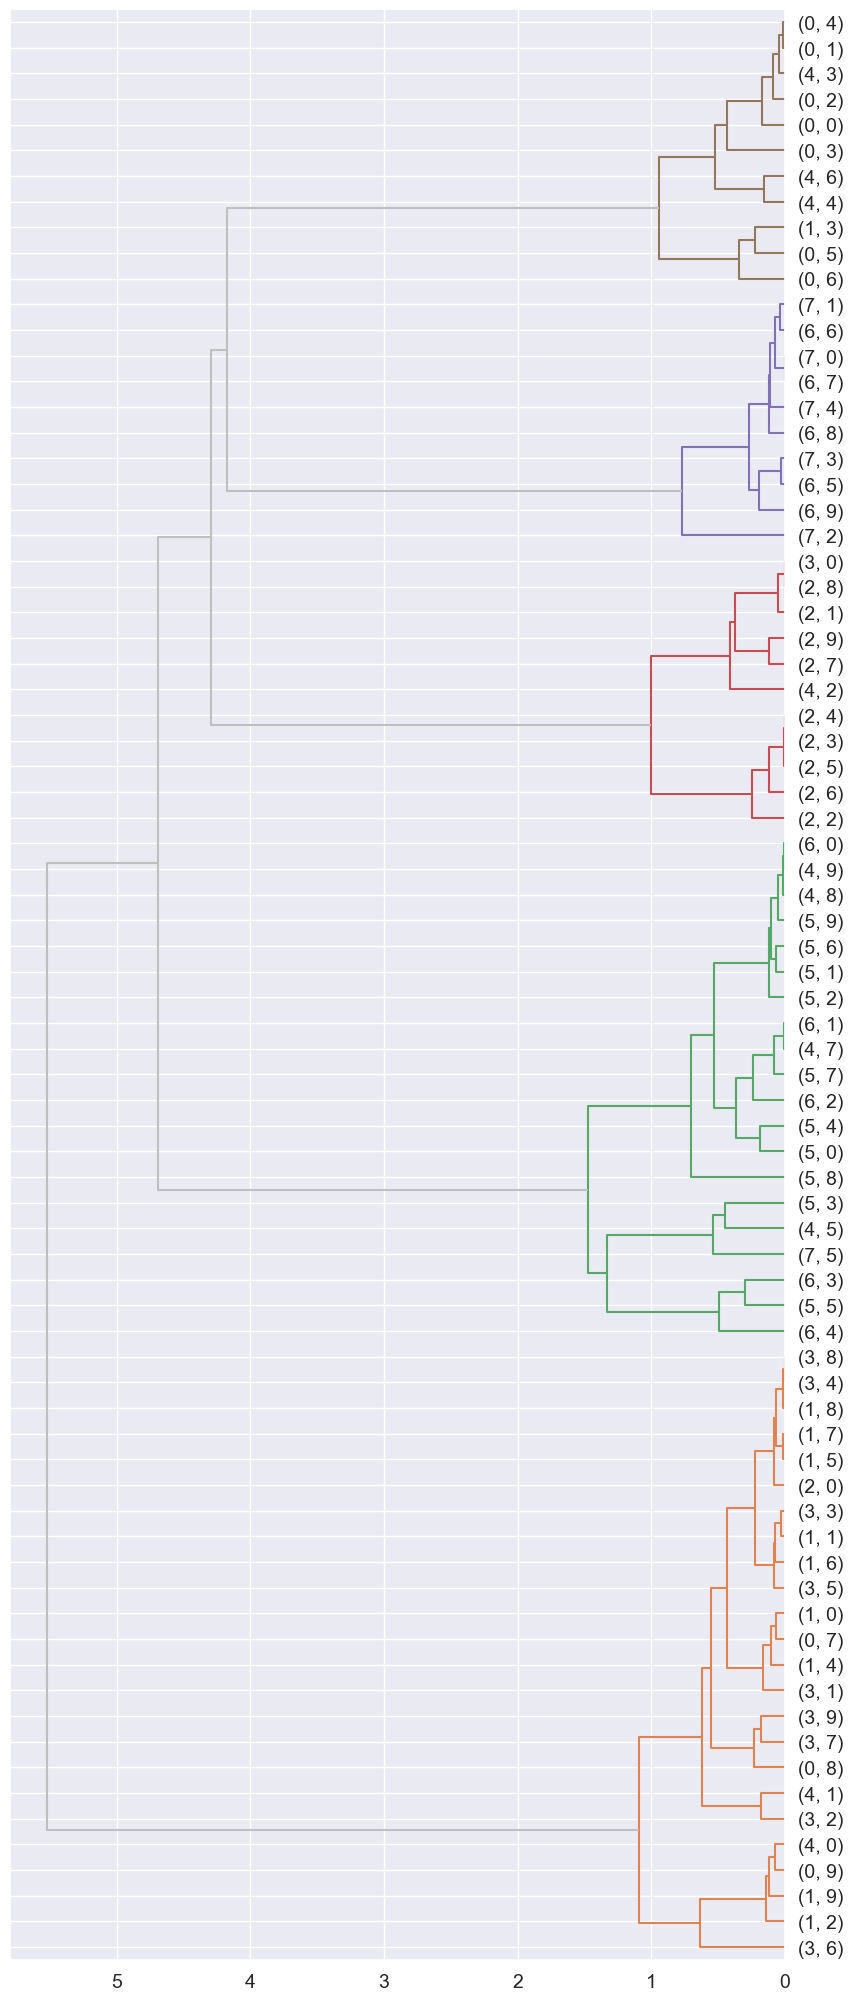

In [82]:
fig1 = HAC(THETA)
fig1.linkage_method = linkage
fig1.dist_metric = metric
fig1.color_thresh = 2
fig1.plot()

In [83]:
fig1.get_cluster_labels()
CHUNK['topic_group'] = fig1.CLUSTER_LABELS

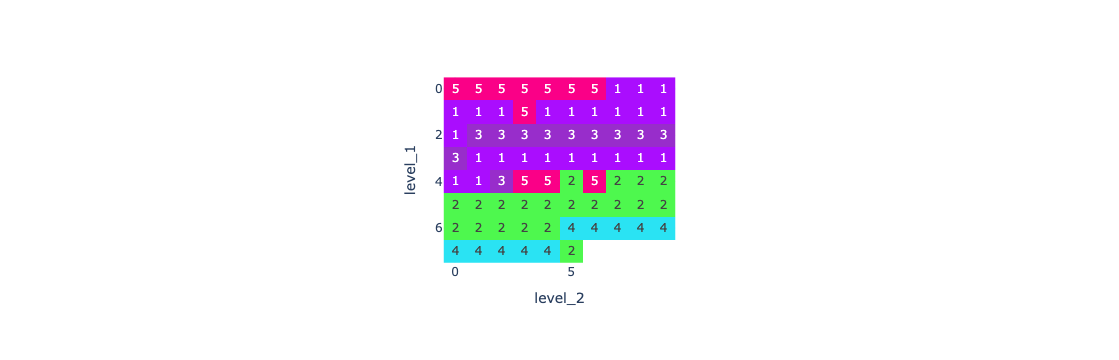

In [84]:
plot_grid(CHUNK.topic_group.unstack())

# Correlate Documents in Topic Space

In [85]:
X = THETA.T.corr()

In [86]:
fig2 = HAC(X)
fig2.linkage_method = linkage
fig2.dist_metric = metric

In [87]:
fig2.color_thresh = 2

<Figure size 640x480 with 0 Axes>

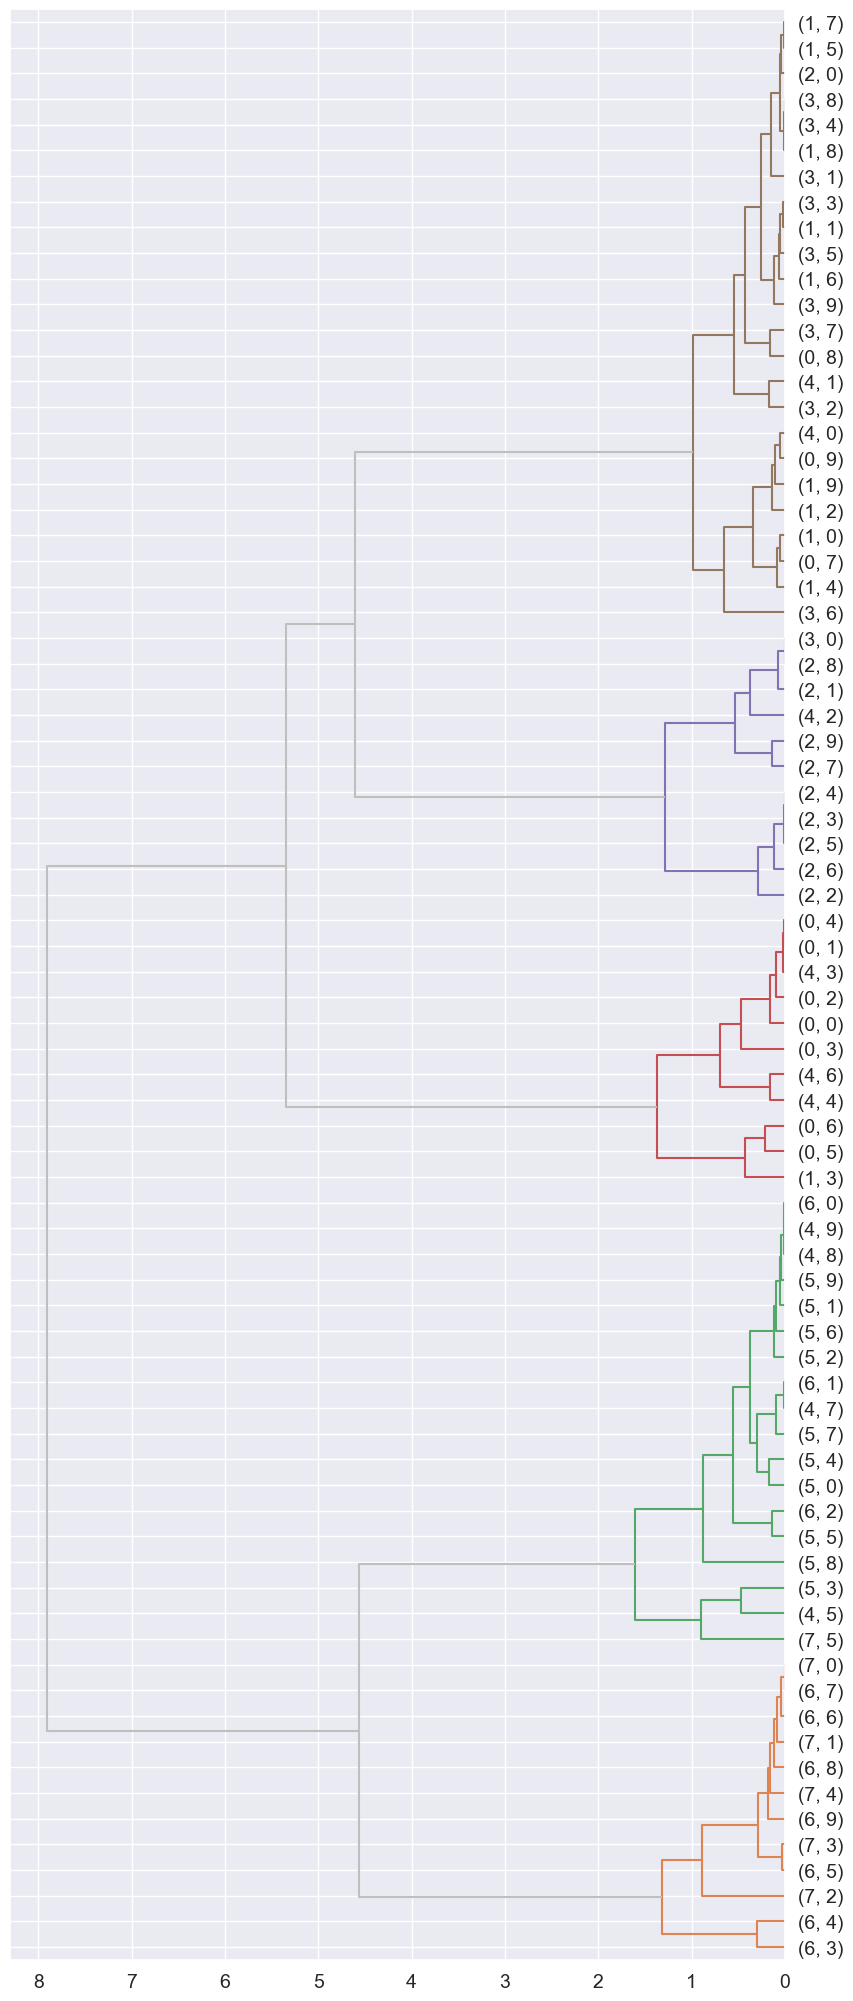

In [88]:
fig2.plot()

In [89]:
fig2.get_cluster_labels()
CHUNK['topic_group_corr'] = fig2.CLUSTER_LABELS
CHUNK.topic_group_corr = CHUNK.topic_group.astype(str)

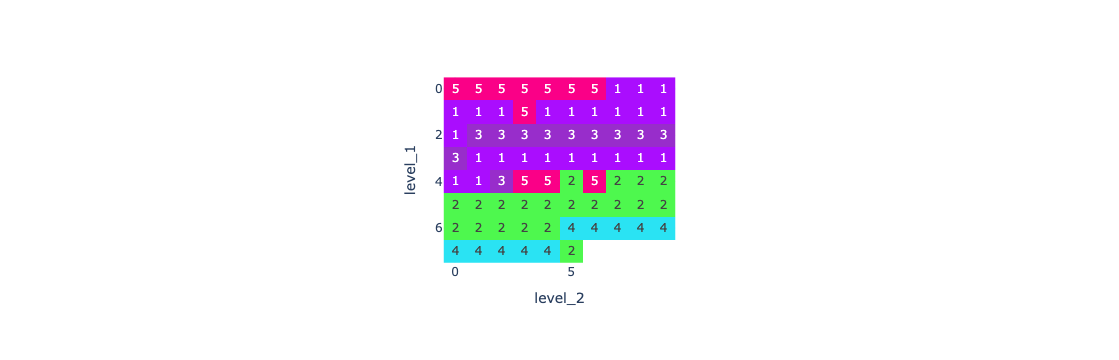

In [90]:
plot_grid(CHUNK.topic_group_corr.unstack())

# Document Similarity in Topic Space

In [95]:
from sklearn.metrics.pairwise import cosine_similarity

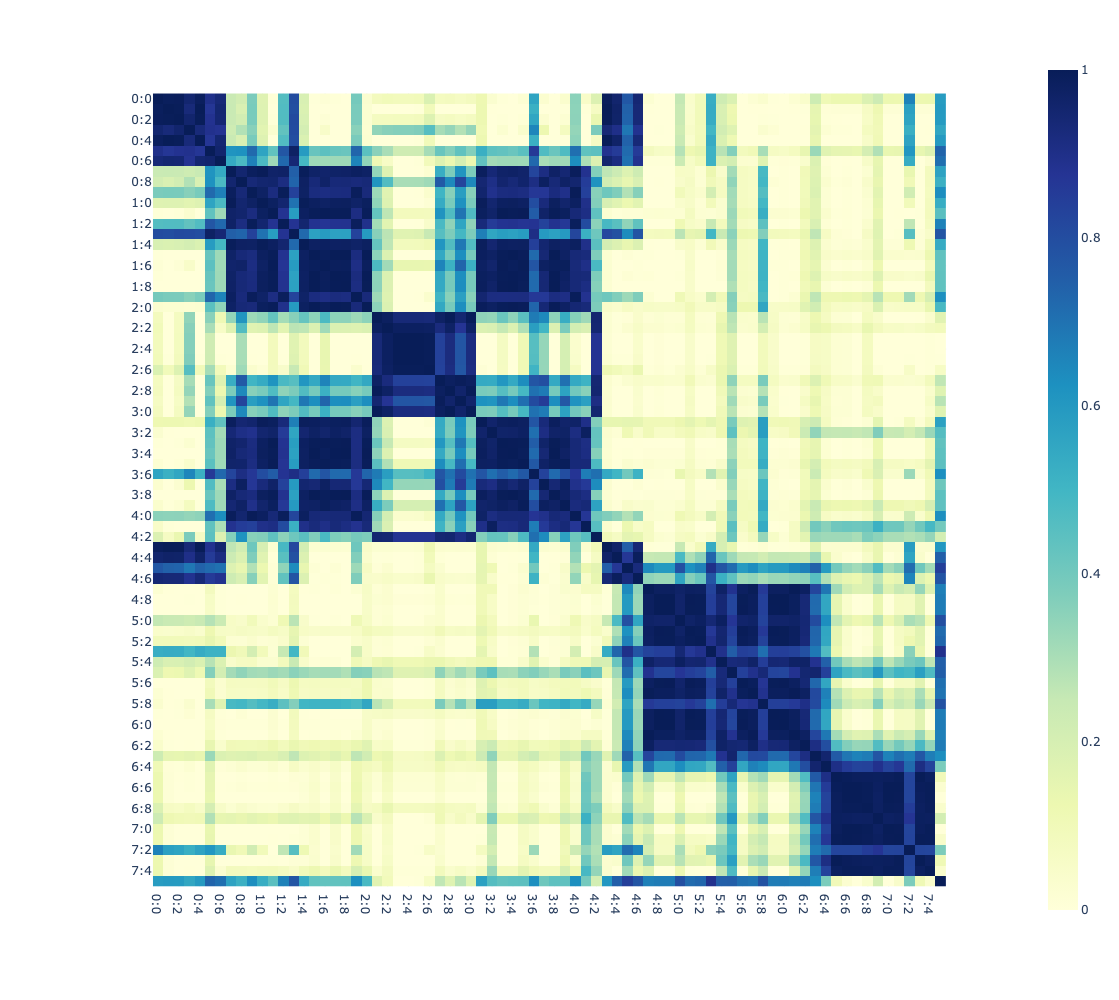

In [96]:
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
f = CHM(THETA_SIM)
f.cmap = px.colors.colorbrewer.YlGnBu
f.plot()

<Figure size 640x480 with 0 Axes>

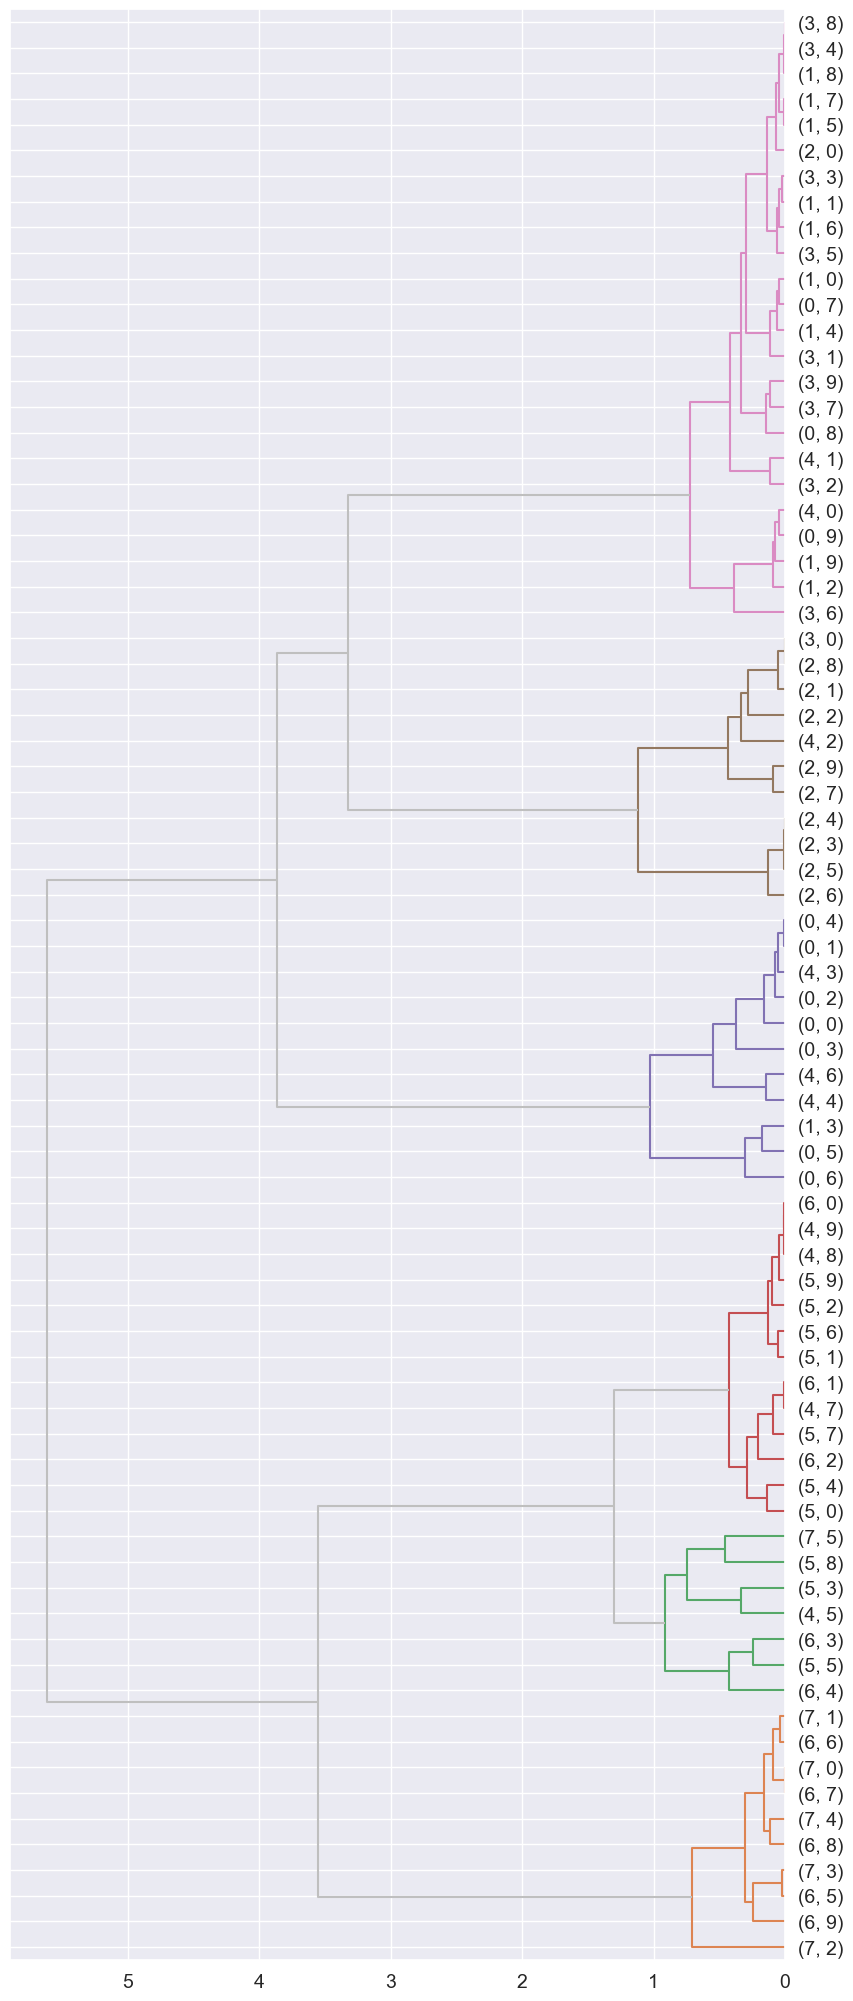

In [108]:
fig3 = HAC(THETA_SIM)
fig3.linkage_method = linkage
fig3.dist_metric = metric
fig3.color_thresh = 1.3
fig3.plot()

In [109]:
fig3.get_cluster_labels()
CHUNK['doc_sim'] = fig3.CLUSTER_LABELS
CHUNK.doc_sim = CHUNK.doc_sim.astype(str)

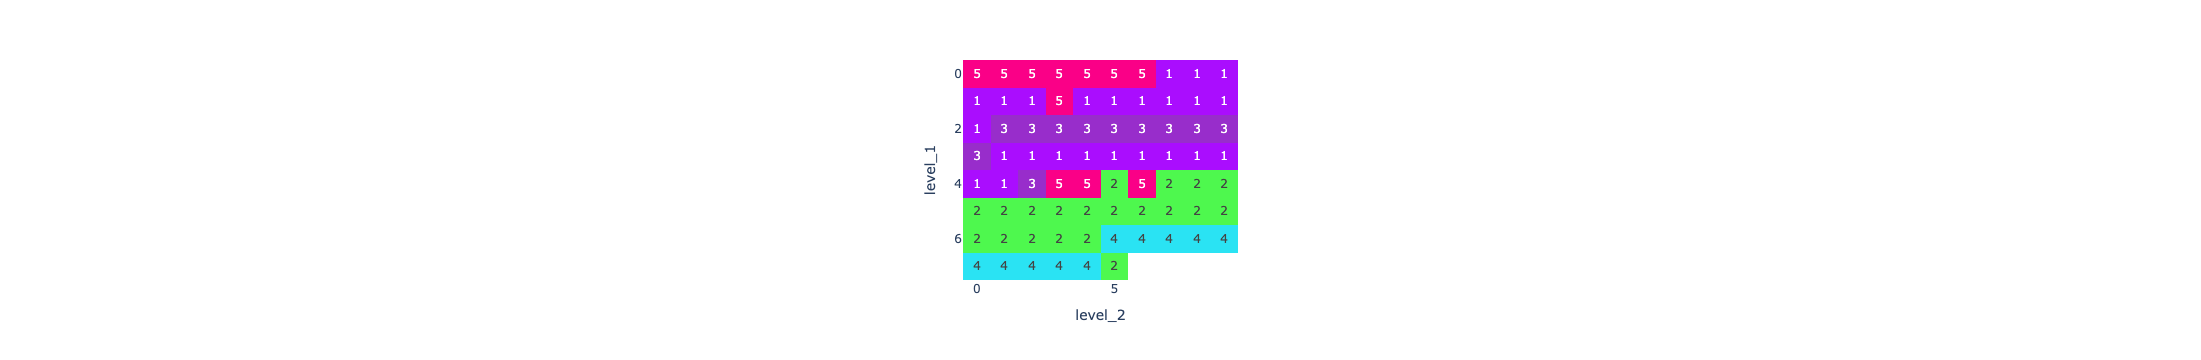

In [110]:
plot_grid(CHUNK.topic_group_corr.unstack())

In [112]:
CHUNK.loc[(2,2)].chunk_str

'dos, ni tres, y viendo que sólo había una mata con su espiga, se llenó de angustia el corazón de la muchacha. —¡Ay, pecadora, desgraciada de mí! ¿A dónde he de ir a conseguir una red de maíz, como se me ha ordenado?, exclamó. Y en seguida se puso a invocar al Chahal de la comida para que llegara y se la llevase. —lxtoh, Ixcanil, Ixcacau,l vosotras las que cocéis el maíz; y tú Chahal, guardián de la comida de Hunbaíz; y Hunchouén!, dijo la muchacha. Y a continuación cogió las barbas, los pelos rojos de la mazor- ca. Luego los arregló en la red como mazorcas de maíz y la gran red se llenó completamente. Volvióse en seguida la joven; los animales del campo iban cargando la red, y cuando llegaron, fueron a dejar la carga a un rincón de la casa, como si ella la hubiera llevado. Llegó entonces la vieja y luego que vio el maíz que había en la gran red, exclamó: —¿De dónde has traído todo este maíz? ¿Por ventura acabaste con nuestra milpa y te la has traído toda para acá? Iré a ver al instant

In [113]:
CHUNK.loc[(3,1)].chunk_str

'no lloréis, que ahí os dejamos la señal de nuestra suerte, dijeron. Y antes de irse, sembró una (caña) Hunahpú y otra Ixbalanqué; las sembraron en la casa y no en el campo, ni tampoco en tierra húmeda, sino en tierra seca; en medio de su casa las dejaron sembradas. Marcharon entonces, llevando cada uno su cerbatana, y fueron bajando en dirección a Xibalbá. Bajaron rápidamente los escalones y pasaron entre varios ríos y barrancas. Pasaron entre unos pájaros y estos pájaros llamábanse Molay. Pasaron también por un río de podre y por un río de sangre, donde debían ser destruidos según pensaban los de Xibalbá: pero no los tocaron con sus pies, sino que los atravesaron sobre sus cerbatanas. Salieron de allí y llegaron a una encrucijada de cuatro caminos. Ellos sabían muy bien cuáles eran los caminos de Xibalbá el camino negro, el camino blanco,el camino rojo y el camino verde. Así, pues, despa- charon a un animal llamado Xan. Este debía ir a recoger las noticias que lo enviaban a buscar. —

# Document Correlation in Topic Space

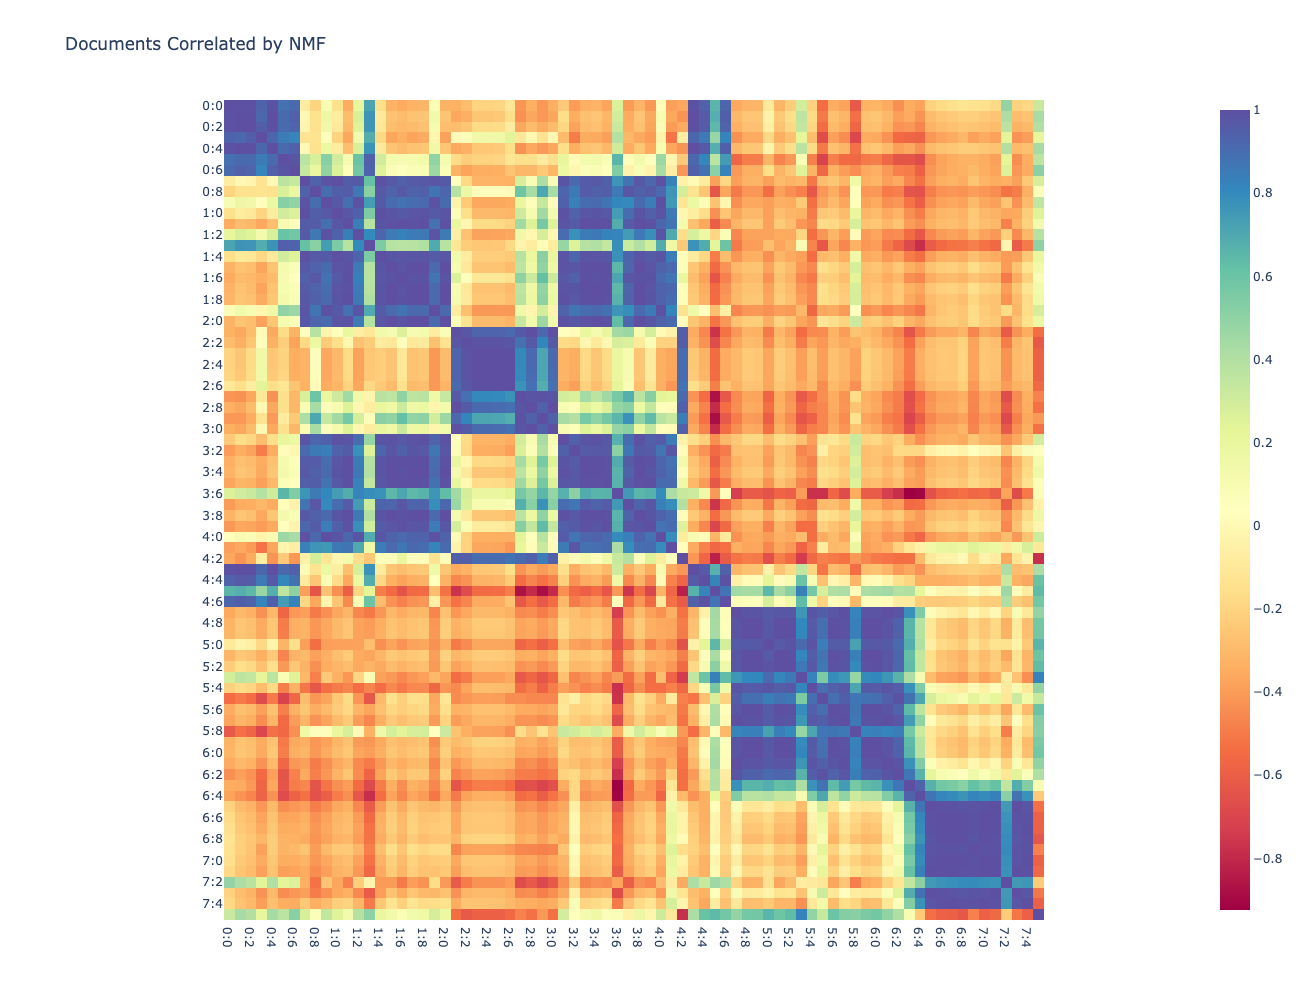

In [91]:
CHM(X, "Documents Correlated by NMF").plot()